# A Data-Driven Solution to Inefficient Bank Marketing Campaigns

## 1. Business Problem

The objective is to predict whether a customer will subscribe to a term deposit (`y = yes/no`) using campaign and client data.

Primary goals:
- Improve targeting efficiency for outbound calls.
- Balance conversion quality (precision) vs conversion volume (recall).
- Maximize campaign profitability through threshold-based decisioning.


In [1]:
# Core libraries
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

# Scikit-learn building blocks
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_validate,
)
from sklearn.metrics import (
    make_scorer,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    auc,
    classification_report,
    confusion_matrix,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

# Consistent visual formatting across the notebook
plt.rcParams.update(
    {
        "figure.figsize": (10, 6),
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "axes.labelsize": 11,
        "axes.grid": True,
        "grid.alpha": 0.2,
        "legend.frameon": False,
    }
)

def apply_professional_axis(ax, title, xlabel, ylabel):
    ax.set_title(title, pad=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    sns.despine(ax=ax)

RANDOM_STATE = 42


## 2. Data Understanding


In [2]:
# Data loading
DATA_PATH = Path("bank.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Could not find dataset at: {DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH, sep=",")

print(f"Dataset shape: {df.shape}")
print(f"Columns ({len(df.columns)}): {list(df.columns)}")
display(df.head())


Dataset shape: (41188, 21)
Columns (21): ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'S', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,S,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


Duplicate rows: 12

Missing values by column:


,missing_count
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0



Target distribution:


,count
y,
no,36548
yes,4640


Positive class rate (y='yes'): 0.1127
Negative class rate (y='no'): 0.8873
Imbalance ratio (no:yes): 7.88:1
Imbalance detected: using class-weighted learning for supported models.


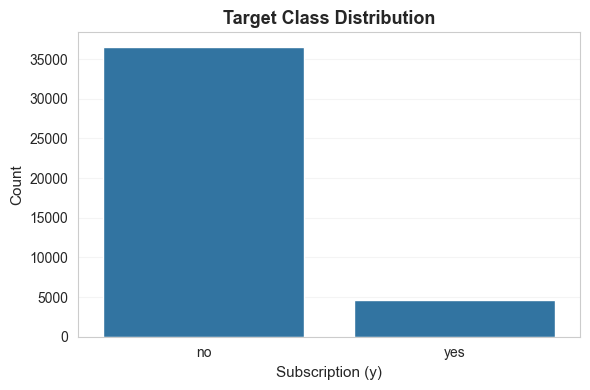

In [ ]:
# Basic data quality and target understanding
print(f"Duplicate rows: {df.duplicated().sum()}")
print()S
print("Missing values by column:")
display(df.isnull().sum().sort_values(ascending=False).to_frame("missing_count"))

if "y" not in df.columns:
    raise ValueError("Expected target column 'y' is missing.")

print()
print("Target distribution:")
target_counts = df["y"].value_counts(dropna=False)
display(target_counts.to_frame("count"))

yes_count = int((df["y"] == "yes").sum())
no_count = int((df["y"] == "no").sum())

target_rate = yes_count / len(df)
negative_rate = no_count / len(df)
imbalance_ratio = (no_count / yes_count) if yes_count > 0 else np.nan
class_imbalance_detected = bool(imbalance_ratio >= 2)

print(f"Positive class rate (y='yes'): {target_rate:.4f}")
print(f"Negative class rate (y='no'): {negative_rate:.4f}")
print(f"Imbalance ratio (no:yes): {imbalance_ratio:.2f}:1")

if class_imbalance_detected:
    print("Imbalance detected: using class-weighted learning for supported models.")
else:
    print("Class imbalance is mild: weighted and unweighted behavior should be similar.")

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="y", order=df["y"].value_counts().index)
plt.title("Target Class Distribution")
plt.xlabel("Subscription (y)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


### 2.1 Class Imbalance Handling

The target is skewed toward `no`, so we explicitly measure imbalance and apply class weighting for supported models.
This improves sensitivity to likely subscribers while preserving the existing pipeline structure.


## 3. Preprocessing


In [4]:
# Preserve original feature engineering and clean data
# 1) Remove duplicates (if any)
# 2) Drop 'duration' to avoid post-call leakage
# 3) Encode target as binary

df_model = df.copy()

duplicate_count = df_model.duplicated().sum()
if duplicate_count > 0:
    df_model = df_model.drop_duplicates().copy()
    print(f"Dropped {duplicate_count} duplicate rows. New shape: {df_model.shape}")
else:
    print("No duplicate rows detected.")

if "duration" in df_model.columns:
    df_model = df_model.drop(columns=["duration"])
    print("Dropped 'duration' column for realistic prediction setup.")

# Target encoding
df_model["y"] = df_model["y"].map({"yes": 1, "no": 0})
if df_model["y"].isna().any():
    raise ValueError("Target mapping produced NaN values. Check target labels in 'y'.")

X = df_model.drop(columns=["y"])
y = df_model["y"].astype(int)

# Feature type separation for ColumnTransformer
numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

print(f"Total features: {X.shape[1]}")
print(f"Numerical features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")


def build_one_hot_encoder():
    # Compatibility helper for sklearn versions
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_preprocessor():
    # Leak-safe preprocessing: scale numerics + one-hot categoricals
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_features),
            ("cat", build_one_hot_encoder(), categorical_features),
        ],
        remainder="drop",
    )


# Hold-out split kept to preserve baseline functionality
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")


Dropped 12 duplicate rows. New shape: (41176, 21)
Dropped 'duration' column for realistic prediction setup.
Total features: 19
Numerical features (9): ['age', 'campaign', 'pdays', 'previous', 'S', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categorical features (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Train shape: (28823, 19), Test shape: (12353, 19)


## 4. Model Pipeline


In [5]:
# Build model pipelines with preprocessing inside to prevent data leakage

def build_pipeline(model):
    return Pipeline(
        steps=[
            ("preprocessor", build_preprocessor()),
            ("model", model),
        ]
    )

use_class_weight = class_imbalance_detected
log_reg_class_weight = "balanced" if use_class_weight else None
rf_class_weight = "balanced" if use_class_weight else None

print(
    "Imbalance handling strategy:",
    f"LogisticRegression(class_weight={log_reg_class_weight}),",
    f"RandomForest(class_weight={rf_class_weight})",
)

base_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE,
        class_weight=log_reg_class_weight,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight=rf_class_weight,
    ),
    "Gradient Boosting (Default)": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

base_pipelines = {name: build_pipeline(model) for name, model in base_models.items()}

# Preserve original baseline functionality: hold-out comparison
holdout_rows = []
holdout_predictions = {}

for model_name, pipeline in base_pipelines.items():
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    row = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
    }
    holdout_rows.append(row)

    holdout_predictions[model_name] = {"y_pred": y_pred, "y_prob": y_prob, "pipeline": pipeline}

    print()
    print(f"{model_name} - Hold-Out Classification Report")
    print(classification_report(y_test, y_pred, zero_division=0))

holdout_results_df = pd.DataFrame(holdout_rows).set_index("Model").sort_values("ROC-AUC", ascending=False)

print()
print("Hold-Out Model Comparison")
display(holdout_results_df.round(4))


Imbalance handling strategy: LogisticRegression(class_weight=balanced), RandomForest(class_weight=balanced)

Logistic Regression - Hold-Out Classification Report
              precision    recall  f1-score   support

           0       0.95      0.85      0.90     10961
           1       0.36      0.65      0.46      1392

    accuracy                           0.83     12353
   macro avg       0.66      0.75      0.68     12353
weighted avg       0.88      0.83      0.85     12353


Random Forest - Hold-Out Classification Report
              precision    recall  f1-score   support

           0       0.91      0.97      0.94     10961
           1       0.55      0.27      0.36      1392

    accuracy                           0.89     12353
   macro avg       0.73      0.62      0.65     12353
weighted avg       0.87      0.89      0.88     12353


Gradient Boosting (Default) - Hold-Out Classification Report
              precision    recall  f1-score   support

           0       

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Model,,,,,
Gradient Boosting (Default),0.9015,0.6775,0.2399,0.3544,0.8092
Logistic Regression,0.8314,0.3613,0.6466,0.4636,0.8034
Random Forest,0.8929,0.5505,0.2701,0.3624,0.7787


## 5. Hyperparameter Optimization


In [6]:
# Grid search for GradientBoostingClassifier inside a leak-safe pipeline
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

gb_pipeline_for_tuning = build_pipeline(
    GradientBoostingClassifier(random_state=RANDOM_STATE)
)

param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3],
}

grid_search = GridSearchCV(
    estimator=gb_pipeline_for_tuning,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv_strategy,
    n_jobs=-1,
    refit=True,
    verbose=1,
    return_train_score=False,
)

grid_search.fit(X_train, y_train)

best_gb_model = grid_search.best_estimator_
best_idx = grid_search.best_index_
best_cv_mean = grid_search.cv_results_["mean_test_score"][best_idx]
best_cv_std = grid_search.cv_results_["std_test_score"][best_idx]

print("Best Gradient Boosting Parameters:")
print(grid_search.best_params_)
print(f"Best CV ROC-AUC: {best_cv_mean:.4f} +/- {best_cv_std:.4f}")


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Gradient Boosting Parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 300}
Best CV ROC-AUC: 0.7951 +/- 0.0080


## 6. Cross-Validation Results


In [7]:
# Cross-validation across baseline pipelines + tuned Gradient Boosting
scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "roc_auc": "roc_auc",
}

models_for_cv = {
    "Logistic Regression": base_pipelines["Logistic Regression"],
    "Random Forest": base_pipelines["Random Forest"],
    "Gradient Boosting (Default)": base_pipelines["Gradient Boosting (Default)"],
    "Gradient Boosting (Tuned)": best_gb_model,
}

cv_summary_rows = []
cv_fold_tables = {}

for model_name, model_pipeline in models_for_cv.items():
    cv_scores = cross_validate(
        model_pipeline,
        X_train,
        y_train,
        cv=cv_strategy,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,
    )

    fold_df = pd.DataFrame(
        {
            "Fold": np.arange(1, cv_strategy.get_n_splits() + 1),
            "Accuracy": cv_scores["test_accuracy"],
            "Precision": cv_scores["test_precision"],
            "Recall": cv_scores["test_recall"],
            "F1-score": cv_scores["test_f1"],
            "ROC-AUC": cv_scores["test_roc_auc"],
        }
    )
    cv_fold_tables[model_name] = fold_df

    print()
    print("=" * 80)
    print(f"Per-Fold Metrics: {model_name}")
    print("=" * 80)
    display(fold_df.round(4))

    summary_row = {"Model": model_name}
    for metric in ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]:
        summary_row[f"{metric} Mean"] = fold_df[metric].mean()
        summary_row[f"{metric} Std"] = fold_df[metric].std()
    cv_summary_rows.append(summary_row)

cv_summary_df = pd.DataFrame(cv_summary_rows).set_index("Model").sort_index()

print()
print("Cross-Validated Performance Summary (Mean +/- Std)")
display(cv_summary_df.round(4))



Per-Fold Metrics: Logistic Regression


,Fold,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,1,0.8264,0.3498,0.6317,0.4503,0.7961
1,2,0.8272,0.3531,0.6400,0.4551,0.7858
2,3,0.8350,0.3636,0.6169,0.4575,0.8030
3,4,0.8203,0.3298,0.5778,0.4199,0.7709
4,5,0.8255,0.3483,0.6317,0.4491,0.7874



Per-Fold Metrics: Random Forest


,Fold,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,1,0.8933,0.5538,0.2696,0.3627,0.7783
1,2,0.8935,0.5577,0.2677,0.3617,0.7745
2,3,0.8945,0.5695,0.2646,0.3613,0.7815
3,4,0.8898,0.5201,0.2789,0.3631,0.7615
4,5,0.8966,0.5820,0.2897,0.3868,0.7748



Per-Fold Metrics: Gradient Boosting (Default)


,Fold,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,1,0.9006,0.6597,0.2419,0.3540,0.7977
1,2,0.8992,0.6494,0.2308,0.3405,0.7958
2,3,0.9016,0.6828,0.2385,0.3535,0.8073
3,4,0.8995,0.6336,0.2558,0.3644,0.7737
4,5,0.9034,0.6840,0.2635,0.3804,0.7902



Per-Fold Metrics: Gradient Boosting (Tuned)


,Fold,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,1,0.9010,0.6523,0.2573,0.3691,0.7980
1,2,0.8990,0.6308,0.2523,0.3604,0.8000
2,3,0.9013,0.6680,0.2477,0.3614,0.8044
3,4,0.8987,0.6199,0.2589,0.3652,0.7812
4,5,0.9013,0.6449,0.2743,0.3849,0.7922



Cross-Validated Performance Summary (Mean +/- Std)


,Accuracy Mean,Accuracy Std,Precision Mean,Precision Std,Recall Mean,Recall Std,F1-score Mean,F1-score Std,ROC-AUC Mean,ROC-AUC Std
Model,,,,,,,,,,
Gradient Boosting (Default),0.9009,0.0017,0.6619,0.0217,0.2461,0.0133,0.3586,0.0149,0.7929,0.0124
Gradient Boosting (Tuned),0.9003,0.0013,0.6432,0.0187,0.2581,0.0101,0.3682,0.0099,0.7951,0.0090
Logistic Regression,0.8269,0.0053,0.3489,0.0122,0.6196,0.0248,0.4464,0.0152,0.7886,0.0121
Random Forest,0.8936,0.0025,0.5566,0.0232,0.2741,0.0102,0.3671,0.0110,0.7741,0.0076


## 7. Evaluation & Curves


Tuned Gradient Boosting - Hold-Out Classification Report (threshold=0.5)
              precision    recall  f1-score   support

           0       0.91      0.98      0.95     10961
           1       0.63      0.25      0.36      1392

    accuracy                           0.90     12353
   macro avg       0.77      0.62      0.65     12353
weighted avg       0.88      0.90      0.88     12353



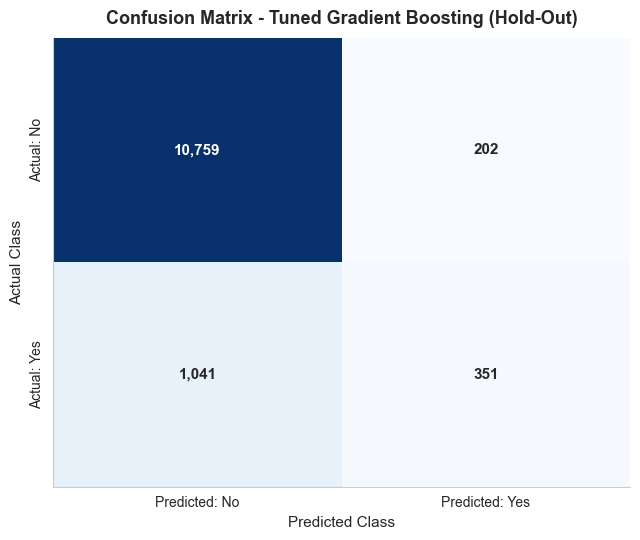

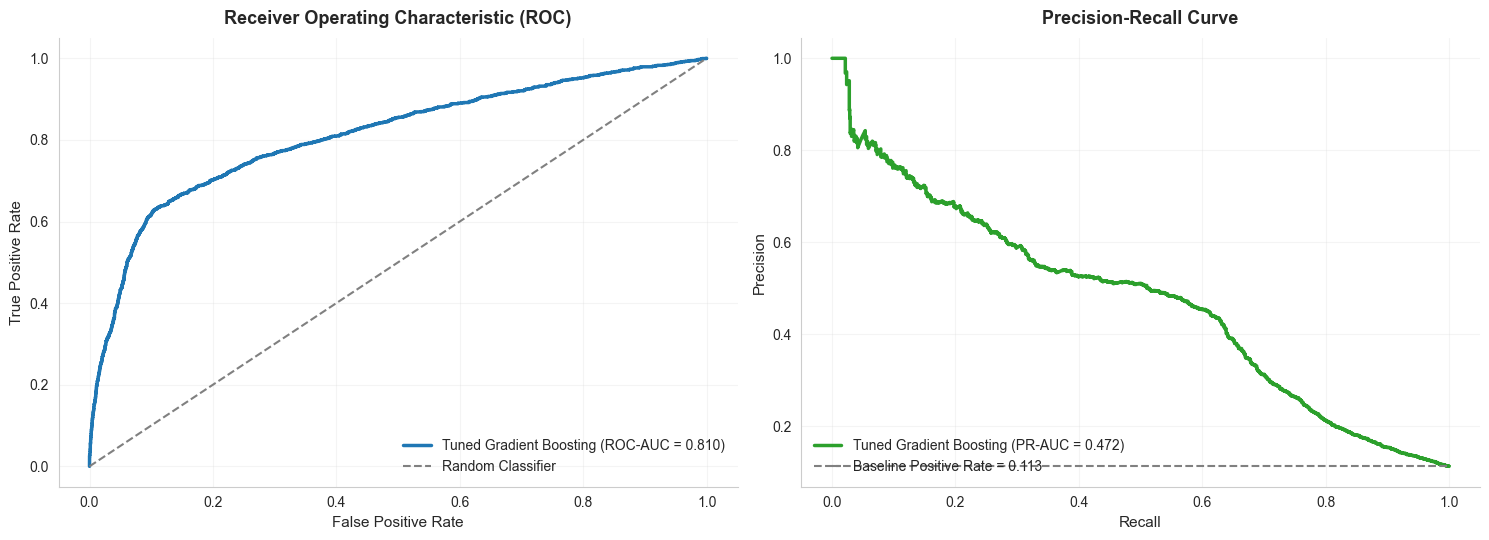

In [8]:
# Evaluate tuned best model on hold-out test set
best_gb_model.fit(X_train, y_train)
y_test_prob = best_gb_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob >= 0.5).astype(int)

print("Tuned Gradient Boosting - Hold-Out Classification Report (threshold=0.5)")
print(classification_report(y_test, y_test_pred, zero_division=0))

# Confusion matrix heatmap
cm = confusion_matrix(y_test, y_test_pred)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(
    cm,
    annot=True,
    fmt=",d",
    cmap="Blues",
    cbar=False,
    annot_kws={"size": 11, "weight": "bold"},
    xticklabels=["Predicted: No", "Predicted: Yes"],
    yticklabels=["Actual: No", "Actual: Yes"],
    ax=ax,
)
apply_professional_axis(
    ax,
    "Confusion Matrix - Tuned Gradient Boosting (Hold-Out)",
    "Predicted Class",
    "Actual Class",
)
plt.tight_layout()
plt.show()

# ROC and PR curves with AUC values
roc_auc_value = roc_auc_score(y_test, y_test_prob)
fpr, tpr, _ = roc_curve(y_test, y_test_prob)

pr_precision, pr_recall, _ = precision_recall_curve(y_test, y_test_prob)
pr_auc_value = auc(pr_recall, pr_precision)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

axes[0].plot(
    fpr,
    tpr,
    label=f"Tuned Gradient Boosting (ROC-AUC = {roc_auc_value:.3f})",
    linewidth=2.5,
    color="#1f77b4",
)
axes[0].plot([0, 1], [0, 1], "--", color="gray", label="Random Classifier")
apply_professional_axis(
    axes[0],
    "Receiver Operating Characteristic (ROC)",
    "False Positive Rate",
    "True Positive Rate",
)
axes[0].legend(loc="lower right")

axes[1].plot(
    pr_recall,
    pr_precision,
    label=f"Tuned Gradient Boosting (PR-AUC = {pr_auc_value:.3f})",
    linewidth=2.5,
    color="#2ca02c",
)
axes[1].hlines(
    y=y_test.mean(),
    xmin=0,
    xmax=1,
    colors="gray",
    linestyles="--",
    label=f"Baseline Positive Rate = {y_test.mean():.3f}",
)
apply_professional_axis(
    axes[1],
    "Precision-Recall Curve",
    "Recall",
    "Precision",
)
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.show()


## 8. Threshold Optimization


In [9]:
# Threshold tuning on hold-out probabilities
thresholds = [0.3, 0.4, 0.5, 0.6]
threshold_rows = []

for threshold in thresholds:
    threshold_pred = (y_test_prob >= threshold).astype(int)
    threshold_rows.append(
        {
            "Threshold": threshold,
            "Accuracy": accuracy_score(y_test, threshold_pred),
            "Precision": precision_score(y_test, threshold_pred, zero_division=0),
            "Recall": recall_score(y_test, threshold_pred, zero_division=0),
            "F1-score": f1_score(y_test, threshold_pred, zero_division=0),
            "Calls": int(threshold_pred.sum()),
        }
    )

threshold_metrics_df = pd.DataFrame(threshold_rows)
recommended_threshold_f1 = float(
    threshold_metrics_df.loc[threshold_metrics_df["F1-score"].idxmax(), "Threshold"]
)

print("Threshold Metrics (Tuned GB, hold-out set)")
display(threshold_metrics_df.round(4))
print(f"Recommended threshold by F1-score: {recommended_threshold_f1:.2f}")


Threshold Metrics (Tuned GB, hold-out set)


,Threshold,Accuracy,Precision,Recall,F1-score,Calls
0,0.3,0.8901,0.5137,0.4698,0.4908,1273
1,0.4,0.8948,0.5560,0.3283,0.4128,822
2,0.5,0.8994,0.6347,0.2522,0.3609,553
3,0.6,0.8983,0.6868,0.1796,0.2847,364


Recommended threshold by F1-score: 0.30


## 9. Cost-Benefit Simulation


### 9.1 Lift Chart and Baseline Business Comparison

This section evaluates commercial impact beyond pure model metrics.
It adds a lift chart and compares precision, recall, and ROI against a random baseline at matched call volume.


Campaign Profit Simulation - Model vs Random Baseline


,Threshold,Calls Made,True Positives,False Positives,Precision,Recall,ROI,Revenue,Cost,Net Profit,Random Net Profit,Net Profit Improvement vs Random (%),Recommendation
0,0.3,1273,654,619,0.5137,0.4698,11.8437,327000,25460,301540,42040,617.2693,BEST
1,0.4,822,457,365,0.5560,0.3283,12.8990,228500,16440,212060,29560,617.3884,
2,0.5,553,351,202,0.6347,0.2522,14.8680,175500,11060,164440,16440,900.2433,
3,0.6,364,250,114,0.6868,0.1796,16.1703,125000,7280,117720,12220,863.3388,


Requested Comparison Table


,Threshold,Precision,Random Precision,Recall,Random Recall,ROI,Random ROI,Net Profit,Random Net Profit
0,0.3,0.5137,0.1060,0.4698,0.0970,11.8437,1.6512,301540,42040
1,0.4,0.5560,0.1119,0.3283,0.0661,12.8990,1.7981,212060,29560
2,0.5,0.6347,0.0995,0.2522,0.0395,14.8680,1.4864,164440,16440
3,0.6,0.6868,0.1071,0.1796,0.0280,16.1703,1.6786,117720,12220


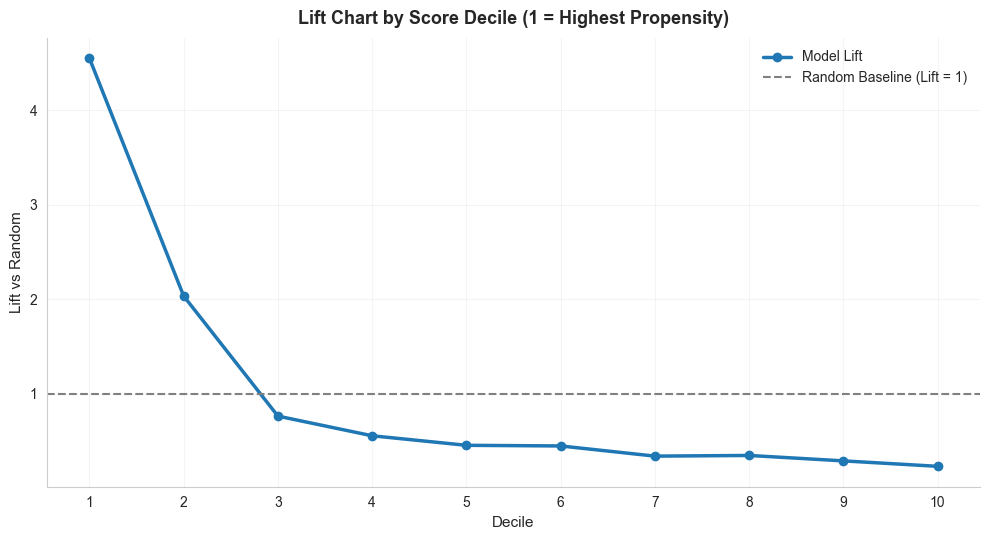

Lift Table (by Decile)


,Decile,Customers,Responders,Response Rate,Lift
0,1,1236,634,0.5129,4.5520
1,2,1235,283,0.2291,2.0335
2,3,1235,106,0.0858,0.7617
3,4,1235,77,0.0623,0.5533
4,5,1236,63,0.0510,0.4523
5,6,1235,62,0.0502,0.4455
6,7,1235,47,0.0381,0.3377
7,8,1235,48,0.0389,0.3449
8,9,1235,40,0.0324,0.2874
9,10,1236,32,0.0259,0.2298


Precision/Recall/ROI Comparison at Threshold 0.30


,Strategy,Precision,Recall,ROI,Net Profit
0,Model Targeting,0.5137,0.4698,11.8437,301540.0
1,Random Baseline,0.1060,0.0970,1.6512,42040.0


**Business interpretation**

- The top decile lift is **4.55x**, meaning the highest-scored 10% of customers are much more likely to subscribe than random outreach.
- At threshold **0.30**, model targeting delivers **301,540** net profit versus **42,040** for random targeting.
- Precision improves from **0.106** (random) to **0.514** (model), reducing wasted calls.
- Recall improves from **0.097** to **0.470**, capturing more true subscribers.
- ROI uplift versus random at this threshold is **617.3%**.


Executive Summary:
Select threshold 0.30: it delivers the highest net profit (301,540) and outperforms random targeting by 617.3%.
At this threshold, the campaign makes 1,273 calls, captures 654 true subscriptions, and limits false-positive outreach to 619 customers.


In [10]:
# Business simulation assumptions + lift chart + baseline comparison
COST_PER_CALL = 20
REVENUE_PER_SUCCESS = 500

simulation_rows = []
random_rows = []

rng = np.random.default_rng(RANDOM_STATE)
actual_positive_total = int(y_test.sum())

for threshold in thresholds:
    pred = (y_test_prob >= threshold).astype(int)

    calls = int(pred.sum())
    tp = int(((pred == 1) & (y_test.values == 1)).sum())
    fp = int(((pred == 1) & (y_test.values == 0)).sum())

    campaign_cost = calls * COST_PER_CALL
    revenue = tp * REVENUE_PER_SUCCESS
    net_profit = revenue - campaign_cost

    precision_val = tp / calls if calls > 0 else 0.0
    recall_val = tp / actual_positive_total if actual_positive_total > 0 else 0.0
    roi_val = net_profit / campaign_cost if campaign_cost > 0 else np.nan

    simulation_rows.append(
        {
            "Threshold": threshold,
            "Calls Made": calls,
            "True Positives": tp,
            "False Positives": fp,
            "Precision": precision_val,
            "Recall": recall_val,
            "Revenue": revenue,
            "Cost": campaign_cost,
            "Net Profit": net_profit,
            "ROI": roi_val,
        }
    )

    if calls > 0:
        sampled_idx = rng.choice(y_test.index.to_numpy(), size=calls, replace=False)
        random_tp = int(y_test.loc[sampled_idx].sum())
    else:
        random_tp = 0

    random_fp = calls - random_tp
    random_cost = campaign_cost
    random_revenue = random_tp * REVENUE_PER_SUCCESS
    random_net = random_revenue - random_cost

    random_precision = random_tp / calls if calls > 0 else 0.0
    random_recall = random_tp / actual_positive_total if actual_positive_total > 0 else 0.0
    random_roi = random_net / random_cost if random_cost > 0 else np.nan

    random_rows.append(
        {
            "Threshold": threshold,
            "Calls Made": calls,
            "True Positives": random_tp,
            "False Positives": random_fp,
            "Precision": random_precision,
            "Recall": random_recall,
            "Revenue": random_revenue,
            "Cost": random_cost,
            "Net Profit": random_net,
            "ROI": random_roi,
        }
    )

profit_df = pd.DataFrame(simulation_rows)
random_baseline_df = pd.DataFrame(random_rows)

campaign_profit_summary_df = profit_df.sort_values("Threshold").copy()
campaign_profit_summary_df = campaign_profit_summary_df.merge(
    random_baseline_df[
        ["Threshold", "Net Profit", "Precision", "Recall", "ROI", "True Positives"]
    ].rename(
        columns={
            "Net Profit": "Random Net Profit",
            "Precision": "Random Precision",
            "Recall": "Random Recall",
            "ROI": "Random ROI",
            "True Positives": "Random True Positives",
        }
    ),
    on="Threshold",
    how="left",
)
campaign_profit_summary_df["Net Profit Improvement vs Random (%)"] = (
    (campaign_profit_summary_df["Net Profit"] - campaign_profit_summary_df["Random Net Profit"])
    / campaign_profit_summary_df["Random Net Profit"].replace(0, np.nan).abs()
) * 100

best_idx = campaign_profit_summary_df["Net Profit"].idxmax()
best_profit_row = campaign_profit_summary_df.loc[best_idx].copy()
recommended_threshold_profit = float(best_profit_row["Threshold"])
best_improvement_pct = float(best_profit_row["Net Profit Improvement vs Random (%)"])

campaign_profit_summary_df["Recommendation"] = ""
campaign_profit_summary_df.loc[
    campaign_profit_summary_df["Threshold"] == recommended_threshold_profit,
    "Recommendation",
] = "BEST"

print("Campaign Profit Simulation - Model vs Random Baseline")
display(
    campaign_profit_summary_df[
        [
            "Threshold",
            "Calls Made",
            "True Positives",
            "False Positives",
            "Precision",
            "Recall",
            "ROI",
            "Revenue",
            "Cost",
            "Net Profit",
            "Random Net Profit",
            "Net Profit Improvement vs Random (%)",
            "Recommendation",
        ]
    ].round(4)
)

comparison_df = campaign_profit_summary_df[
    [
        "Threshold",
        "Precision",
        "Random Precision",
        "Recall",
        "Random Recall",
        "ROI",
        "Random ROI",
        "Net Profit",
        "Random Net Profit",
    ]
].copy()
print("Requested Comparison Table")
display(comparison_df.round(4))

# Lift chart (decile-based)
lift_eval_df = (
    pd.DataFrame({"Actual": y_test.values, "Score": y_test_prob})
    .sort_values("Score", ascending=False)
    .reset_index(drop=True)
)
lift_eval_df["Decile"] = pd.qcut(lift_eval_df.index + 1, q=10, labels=np.arange(1, 11))

decile_lift_df = (
    lift_eval_df.groupby("Decile")
    .agg(Customers=("Actual", "count"), Responders=("Actual", "sum"))
    .reset_index()
)
decile_lift_df["Decile"] = decile_lift_df["Decile"].astype(int)
decile_lift_df["Response Rate"] = decile_lift_df["Responders"] / decile_lift_df["Customers"]
baseline_response_rate = lift_eval_df["Actual"].mean()
decile_lift_df["Lift"] = (
    decile_lift_df["Response Rate"] / baseline_response_rate if baseline_response_rate > 0 else np.nan
)
decile_lift_df = decile_lift_df.sort_values("Decile")

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(
    decile_lift_df["Decile"],
    decile_lift_df["Lift"],
    marker="o",
    linewidth=2.5,
    color="#1f77b4",
    label="Model Lift",
)
ax.axhline(1.0, linestyle="--", color="gray", label="Random Baseline (Lift = 1)")
ax.set_xticks(np.arange(1, 11))
apply_professional_axis(
    ax,
    "Lift Chart by Score Decile (1 = Highest Propensity)",
    "Decile",
    "Lift vs Random",
)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

print("Lift Table (by Decile)")
display(decile_lift_df.round(4))

selected_comparison_df = pd.DataFrame(
    {
        "Strategy": ["Model Targeting", "Random Baseline"],
        "Precision": [best_profit_row["Precision"], best_profit_row["Random Precision"]],
        "Recall": [best_profit_row["Recall"], best_profit_row["Random Recall"]],
        "ROI": [best_profit_row["ROI"], best_profit_row["Random ROI"]],
        "Net Profit": [best_profit_row["Net Profit"], best_profit_row["Random Net Profit"]],
    }
)
print(f"Precision/Recall/ROI Comparison at Threshold {recommended_threshold_profit:.2f}")
display(selected_comparison_df.round(4))

top_decile_lift = float(decile_lift_df.loc[decile_lift_df["Decile"] == 1, "Lift"].iloc[0])

roi_uplift_pct = np.nan
if pd.notnull(best_profit_row["Random ROI"]) and best_profit_row["Random ROI"] != 0:
    roi_uplift_pct = (
        (best_profit_row["ROI"] - best_profit_row["Random ROI"])
        / abs(best_profit_row["Random ROI"])
    ) * 100

business_text = (
    f"**Business interpretation**\n\n"
    f"- The top decile lift is **{top_decile_lift:.2f}x**, meaning the highest-scored 10% of customers are much more likely to subscribe than random outreach.\n"
    f"- At threshold **{recommended_threshold_profit:.2f}**, model targeting delivers **{best_profit_row['Net Profit']:,.0f}** net profit versus **{best_profit_row['Random Net Profit']:,.0f}** for random targeting.\n"
    f"- Precision improves from **{best_profit_row['Random Precision']:.3f}** (random) to **{best_profit_row['Precision']:.3f}** (model), reducing wasted calls.\n"
    f"- Recall improves from **{best_profit_row['Random Recall']:.3f}** to **{best_profit_row['Recall']:.3f}**, capturing more true subscribers.\n"
    f"- ROI uplift versus random at this threshold is **{roi_uplift_pct:.1f}%**."
)
display(Markdown(business_text))

best_threshold_metrics = threshold_metrics_df.loc[
    threshold_metrics_df["Threshold"] == recommended_threshold_profit
].iloc[0]

print()
print("Executive Summary:")
print(
    f"Select threshold {recommended_threshold_profit:.2f}: it delivers the highest net profit "
    f"({best_profit_row['Net Profit']:,.0f}) and outperforms random targeting by "
    f"{best_improvement_pct:.1f}%."
)
print(
    f"At this threshold, the campaign makes {int(best_profit_row['Calls Made']):,} calls, "
    f"captures {int(best_profit_row['True Positives']):,} true subscriptions, and limits "
    f"false-positive outreach to {int(best_profit_row['False Positives']):,} customers."
)


## 10. Feature Interpretation


### 10.1 SHAP Explainability

Feature importance provides a global ranking of predictors.
SHAP adds transparent per-feature contribution insights to support campaign decisions and model governance.


Top 3 Most Important Features (Model Feature Importance)


,Feature,Importance
0,nr.employed,0.514905
1,euribor3m,0.094227
2,pdays,0.081063


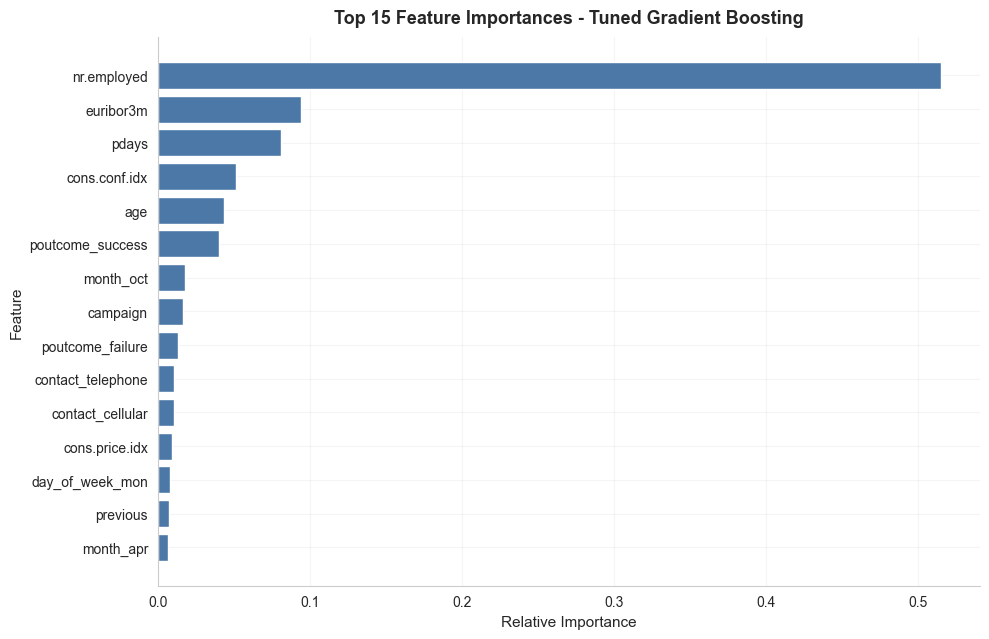

Top 10 Features by Mean |SHAP|


,Feature,Mean |SHAP|
0,nr.employed,0.384865
1,euribor3m,0.144888
2,cons.conf.idx,0.120552
3,contact_telephone,0.112185
4,campaign,0.081621
5,age,0.079031
6,pdays,0.077678
7,contact_cellular,0.073240
8,poutcome_failure,0.056167
9,S,0.049553


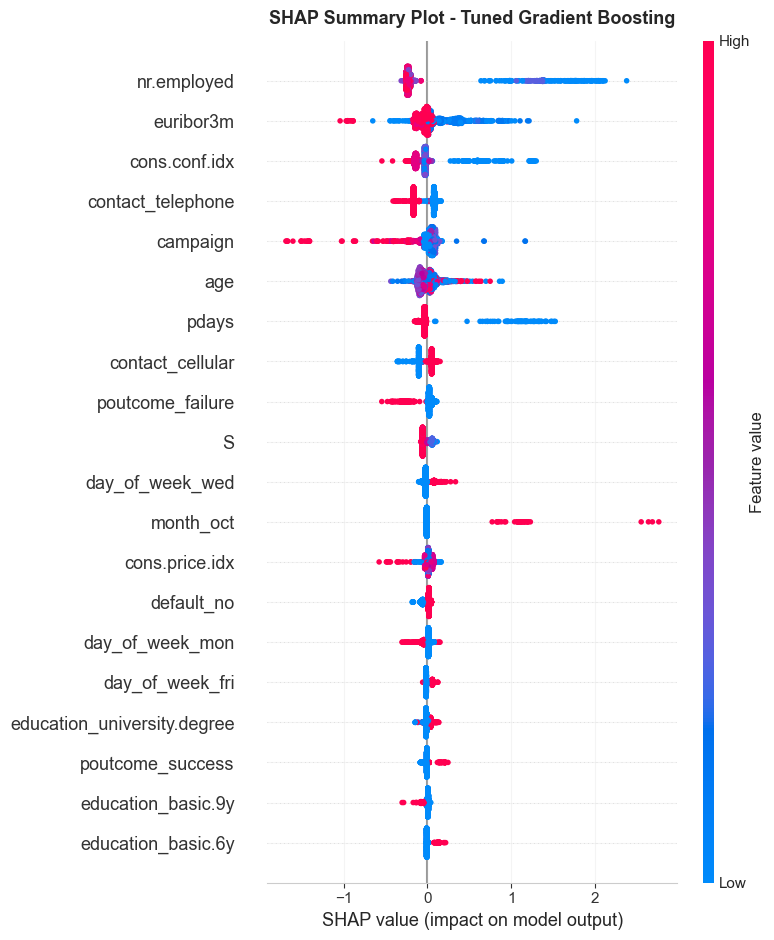

Executive Feature Interpretation (Top 3 by SHAP mean absolute impact)


,Feature,What It Represents,Business Signal,Actionable Strategy
0,nr.employed,A macroeconomic labor-market indicator (number...,Captures economic-cycle shifts; subscription p...,Adjust campaign intensity by economic regime a...
1,euribor3m,Short-term interest-rate benchmark influencing...,Represents rate-sensitivity in customer decisi...,Time high-volume outreach and rate-focused mes...
2,cons.conf.idx,Predictive feature: cons.conf.idx.,Encodes customer or campaign context correlate...,Operationalize this variable in segmentation a...


### 1. nr.employed
- **What it represents:** A macroeconomic labor-market indicator (number of employed people).
- **Signal captured:** Captures economic-cycle shifts; subscription propensity changes with confidence and savings behavior.
- **Actionable strategy:** Adjust campaign intensity by economic regime and prioritize high-propensity segments when labor conditions favor savings uptake.

### 2. euribor3m
- **What it represents:** Short-term interest-rate benchmark influencing perceived deposit value.
- **Signal captured:** Represents rate-sensitivity in customer decisions to lock funds into term deposits.
- **Actionable strategy:** Time high-volume outreach and rate-focused messaging when market-rate context supports stronger conversion economics.

### 3. cons.conf.idx
- **What it represents:** Predictive feature: cons.conf.idx.
- **Signal captured:** Encodes customer or campaign context correlated with subscription propensity.
- **Actionable strategy:** Operationalize this variable in segmentation and script personalization to raise campaign ROI.

In [12]:
# Feature importance + SHAP explainability for the tuned best model
trained_preprocessor = best_gb_model.named_steps["preprocessor"]
trained_model = best_gb_model.named_steps["model"]

feature_names = trained_preprocessor.get_feature_names_out()
clean_feature_names = (
    pd.Series(feature_names)
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

importances = trained_model.feature_importances_
feature_importance_df = (
    pd.DataFrame(
        {
            "Feature": clean_feature_names.values,
            "Importance": importances,
        }
    )
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

top3_features_df = feature_importance_df.head(3).copy()

print("Top 3 Most Important Features (Model Feature Importance)")
display(top3_features_df)

fig, ax = plt.subplots(figsize=(10, 6.5))
plot_df = feature_importance_df.head(15).iloc[::-1]
ax.barh(plot_df["Feature"], plot_df["Importance"], color="#4C78A8")
apply_professional_axis(
    ax,
    "Top 15 Feature Importances - Tuned Gradient Boosting",
    "Relative Importance",
    "Feature",
)
plt.tight_layout()
plt.show()

# SHAP summary for model explainability
shap_importance_df = None
interpretation_source = "model feature importance"

try:
    import shap

    X_test_transformed = trained_preprocessor.transform(X_test)
    if hasattr(X_test_transformed, "toarray"):
        X_test_transformed = X_test_transformed.toarray()

    X_shap_df = pd.DataFrame(X_test_transformed, columns=clean_feature_names.values)
    shap_sample_n = min(2000, len(X_shap_df))
    shap_sample_df = X_shap_df.sample(n=shap_sample_n, random_state=RANDOM_STATE)

    explainer = shap.TreeExplainer(trained_model)
    shap_values = explainer.shap_values(shap_sample_df)

    if isinstance(shap_values, list):
        shap_values_to_plot = shap_values[1] if len(shap_values) > 1 else shap_values[0]
    else:
        shap_values_to_plot = shap_values

    shap_importance_df = (
        pd.DataFrame(
            {
                "Feature": shap_sample_df.columns,
                "Mean |SHAP|": np.abs(shap_values_to_plot).mean(axis=0),
            }
        )
        .sort_values("Mean |SHAP|", ascending=False)
        .reset_index(drop=True)
    )

    print("Top 10 Features by Mean |SHAP|")
    display(shap_importance_df.head(10))

    plt.figure(figsize=(10, 6.5))
    shap.summary_plot(shap_values_to_plot, shap_sample_df, show=False)
    plt.title("SHAP Summary Plot - Tuned Gradient Boosting", pad=12)
    plt.tight_layout()
    plt.show()

    interpretation_source = "SHAP mean absolute impact"

except ImportError:
    print("SHAP is not installed. Run `pip install shap` to enable SHAP summary plots.")
except Exception as exc:
    print(f"SHAP computation skipped due to: {exc}")


def feature_interpretation(feature_name: str):
    library = {
        "nr.employed": {
            "represents": "A macroeconomic labor-market indicator (number of employed people).",
            "signal": "Captures economic-cycle shifts; subscription propensity changes with confidence and savings behavior.",
            "strategy": "Adjust campaign intensity by economic regime and prioritize high-propensity segments when labor conditions favor savings uptake.",
        },
        "euribor3m": {
            "represents": "Short-term interest-rate benchmark influencing perceived deposit value.",
            "signal": "Represents rate-sensitivity in customer decisions to lock funds into term deposits.",
            "strategy": "Time high-volume outreach and rate-focused messaging when market-rate context supports stronger conversion economics.",
        },
        "pdays": {
            "represents": "Days since the client was last contacted in a previous campaign.",
            "signal": "Measures contact recency effects, including engagement readiness versus contact fatigue.",
            "strategy": "Enforce recency-aware contact rules: suppress over-contacted clients and prioritize lapsed, high-potential prospects.",
        },
        "campaign": {
            "represents": "Number of contacts made to the client in the current campaign.",
            "signal": "Signals diminishing returns risk from repeated outreach attempts.",
            "strategy": "Implement frequency caps and escalation logic to preserve agent capacity for higher-yield customers.",
        },
        "age": {
            "represents": "Client life-stage demographic profile.",
            "signal": "Reflects structural differences in liquidity preference and term-deposit appetite by cohort.",
            "strategy": "Deploy cohort-specific messaging and offer framing to increase relevance and conversion rates.",
        },
    }

    if feature_name in library:
        return library[feature_name]

    if "_" in feature_name:
        prefix, level = feature_name.split("_", 1)

        if prefix in {"job", "marital", "education"}:
            return {
                "represents": f"Customer segment flag where {prefix} = {level}.",
                "signal": "Captures structural conversion differences across demographic and professional segments.",
                "strategy": "Prioritize this segment when conversion economics exceed portfolio average and tailor scripts accordingly.",
            }
        if prefix in {"month", "day_of_week", "contact"}:
            return {
                "represents": f"Operational channel/timing indicator ({feature_name}).",
                "signal": "Reflects execution-window and channel effects on response behavior.",
                "strategy": "Shift call scheduling and channel mix toward combinations with superior conversion efficiency.",
            }
        if prefix in {"poutcome", "default", "housing", "loan"}:
            return {
                "represents": f"Financial history/campaign context flag ({feature_name}).",
                "signal": "Signals prior relationship quality and current financial readiness to subscribe.",
                "strategy": "Use as a triage signal for offer type, contact priority, and risk-aware scripting.",
            }

    return {
        "represents": f"Predictive feature: {feature_name}.",
        "signal": "Encodes customer or campaign context correlated with subscription propensity.",
        "strategy": "Operationalize this variable in segmentation and script personalization to raise campaign ROI.",
    }


if shap_importance_df is not None and not shap_importance_df.empty:
    top_features_for_interpretation = shap_importance_df.head(3)["Feature"].tolist()
else:
    top_features_for_interpretation = top3_features_df.head(3)["Feature"].tolist()

interpretation_rows = []
for feature_name in top_features_for_interpretation:
    details = feature_interpretation(feature_name)
    interpretation_rows.append(
        {
            "Feature": feature_name,
            "What It Represents": details["represents"],
            "Business Signal": details["signal"],
            "Actionable Strategy": details["strategy"],
        }
    )

top3_interpretation_df = pd.DataFrame(interpretation_rows)

print(f"Executive Feature Interpretation (Top 3 by {interpretation_source})")
display(top3_interpretation_df)

for idx, item in top3_interpretation_df.iterrows():
    msg_lines = [
        f"### {idx + 1}. {item['Feature']}",
        f"- **What it represents:** {item['What It Represents']}",
        f"- **Signal captured:** {item['Business Signal']}",
        f"- **Actionable strategy:** {item['Actionable Strategy']}",
    ]
    display(Markdown("\n".join(msg_lines)))


## 11. Business Recommendation

The analysis supports one operating decision: execute campaign targeting using the **profit-maximizing threshold**, and standardize outbound prioritization around that cut-off.


In [13]:
# Final decision summary with decisive operating recommendation
selected_threshold = recommended_threshold_profit
selected_perf = threshold_metrics_df.loc[
    threshold_metrics_df["Threshold"] == selected_threshold
].iloc[0]
selected_profit = campaign_profit_summary_df.loc[
    campaign_profit_summary_df["Threshold"] == selected_threshold
].iloc[0]

baseline_threshold = 0.5
baseline_perf = threshold_metrics_df.loc[
    threshold_metrics_df["Threshold"] == baseline_threshold
].iloc[0]
baseline_profit = campaign_profit_summary_df.loc[
    campaign_profit_summary_df["Threshold"] == baseline_threshold
].iloc[0]

calls_delta = int(selected_profit["Calls Made"] - baseline_profit["Calls Made"])
profit_delta = float(selected_profit["Net Profit"] - baseline_profit["Net Profit"])

if calls_delta < 0:
    outreach_impact = (
        f"reduces outreach volume by {abs(calls_delta):,} calls versus threshold {baseline_threshold:.2f} "
        f"while improving economics"
    )
elif calls_delta > 0:
    outreach_impact = (
        f"expands outreach by {calls_delta:,} calls versus threshold {baseline_threshold:.2f} "
        f"to capture materially more conversions"
    )
else:
    outreach_impact = f"keeps outreach volume unchanged versus threshold {baseline_threshold:.2f}"

decision_summary_df = pd.DataFrame(
    {
        "Selection Logic": ["Best F1-score", "Best Net Profit"],
        "Recommended Threshold": [recommended_threshold_f1, recommended_threshold_profit],
    }
)

print("Decision Summary")
display(decision_summary_df.round(2))

recommendation_lines = [
    "### Decisive Recommendation",
    "",
    f"Adopt **threshold {selected_threshold:.2f}** as the production decision rule for campaign targeting.",
    "",
    (
        f"- It delivers the **highest net profit** at **{selected_profit['Net Profit']:,.0f}**, "
        f"exceeding threshold {baseline_threshold:.2f} by **{profit_delta:,.0f}**."
    ),
    (
        f"- It maintains an effective precision-recall profile (**Precision = {selected_perf['Precision']:.3f}**, "
        f"**Recall = {selected_perf['Recall']:.3f}**) and improves recall versus the default 0.50 setting."
    ),
    (
        f"- Versus random targeting at the same call volume, expected net profit improves by "
        f"**{best_improvement_pct:.1f}%**."
    ),
    f"- Operationally, this threshold **{outreach_impact}**, creating superior campaign ROI.",
    "",
    (
        f"**Directive:** Execute the next campaign wave at threshold **{selected_threshold:.2f}** and retain this "
        "standard until monitoring signals indicate recalibration."
    ),
]
recommendation_md = "\n".join(recommendation_lines)
display(Markdown(recommendation_md))


Decision Summary


,Selection Logic,Recommended Threshold
0,Best F1-score,0.3
1,Best Net Profit,0.3


### Decisive Recommendation

Adopt **threshold 0.30** as the production decision rule for campaign targeting.

- It delivers the **highest net profit** at **301,540**, exceeding threshold 0.50 by **137,100**.
- It maintains an effective precision-recall profile (**Precision = 0.514**, **Recall = 0.470**) and improves recall versus the default 0.50 setting.
- Versus random targeting at the same call volume, expected net profit improves by **617.3%**.
- Operationally, this threshold **expands outreach by 720 calls versus threshold 0.50 to capture materially more conversions**, creating superior campaign ROI.

**Directive:** Execute the next campaign wave at threshold **0.30** and retain this standard until monitoring signals indicate recalibration.

## 12. Deployment Strategy

### Batch Scoring Workflow
- Run weekly or daily batch scoring on the latest CRM customer snapshot.
- Generate probability scores (`p_subscribe`) for all eligible contacts through the production pipeline.
- Persist scores with model version, scoring timestamp, and data snapshot ID for traceability.

### CRM Integration
- Push scored records into CRM campaign tables with customer ID, score, threshold flag, and recommended action.
- Expose score bands (high/medium/low propensity) to campaign managers for queue planning.

### Probability Threshold Filtering
- Apply the production threshold (**0.30**) to filter outreach-eligible customers.
- Route above-threshold contacts into active calling queues and suppress below-threshold records.

### Campaign Execution Logic
- Rank eligible customers by score descending and execute top-down by daily call-center capacity.
- Enforce contact-frequency caps to prevent low-yield repeat outreach.
- Capture outcomes (contacted, converted, declined, unreachable) for feedback into retraining.

### Monthly Retraining Plan
- Retrain monthly using latest labeled campaign outcomes and refreshed macro indicators.
- Evaluate challenger vs champion on both validation metrics and recent business KPIs.
- Promote only after analytics, business, and risk sign-off.


### 12.1 Model Serialization (Deployment Readiness)

Save a versioned model artifact with threshold and metadata for reproducible batch scoring and audit traceability.


In [14]:
# Serialize trained model artifact with timestamped versioning
from datetime import datetime
import joblib

artifact_dir = Path("artifacts")
artifact_dir.mkdir(parents=True, exist_ok=True)

utc_now = datetime.utcnow()
model_version_timestamp = utc_now.strftime("%Y-%m-%d %H:%M:%S UTC")
model_version_tag = utc_now.strftime("%Y%m%d_%H%M%S")
artifact_path = artifact_dir / f"bank_marketing_model_{model_version_tag}.joblib"

model_artifact = {
    "model": best_gb_model,
    "model_name": "Gradient Boosting (Tuned)",
    "recommended_threshold": recommended_threshold_profit,
    "holdout_roc_auc": roc_auc_value,
    "version_timestamp": model_version_timestamp,
}

joblib.dump(model_artifact, artifact_path)

# Versioning comment: register artifact_path and version_timestamp in your model registry.
print(f"Saved model artifact: {artifact_path}")
print(f"Artifact version timestamp: {model_version_timestamp}")


Saved model artifact: artifacts\bank_marketing_model_20260216_094134.joblib
Artifact version timestamp: 2026-02-16 09:41:34 UTC


### 12.2 Load and Score New Data

Load the saved artifact, score a new customer batch, and apply the production threshold.


In [15]:
# Load trained artifact and score a new batch
loaded_artifact = joblib.load(artifact_path)
loaded_model = loaded_artifact["model"]
loaded_threshold = loaded_artifact["recommended_threshold"]

# Example batch (replace with latest CRM extract in production)
new_customer_batch = X_test.head(5).copy()
new_scores = loaded_model.predict_proba(new_customer_batch)[:, 1]

scored_batch = new_customer_batch.copy()
scored_batch["p_subscribe"] = new_scores
scored_batch["target_flag"] = (scored_batch["p_subscribe"] >= loaded_threshold).astype(int)

print(f"Scoring using model version: {loaded_artifact['version_timestamp']}")
display(scored_batch[["p_subscribe", "target_flag"]].round(4))


Scoring using model version: 2026-02-16 09:41:34 UTC


,p_subscribe,target_flag
12694,0.0638,0
879,0.0323,0
12340,0.0527,0
5497,0.0313,0
19257,0.0655,0


## 13. Model Monitoring & Governance

### Metrics to Monitor
- Track **ROC-AUC**, **precision**, and **recall** at the production threshold every campaign cycle.
- Track business overlays: conversion rate, cost per conversion, and net profit per call.

### Drift Tracking
- Monitor **conversion-rate drift** against rolling baseline windows.
- Monitor **feature distribution drift** (for example `nr.employed`, `euribor3m`, `pdays`) via PSI/KS-style diagnostics.
- Investigate major shifts in segment mix, channel mix, or macro context that can alter calibration.

### Retraining Trigger Conditions
- Trigger model review if ROC-AUC drops materially (for example >3-5% relative decline).
- Trigger threshold review when precision/recall at the operating cut-off underperform for consecutive cycles.
- Trigger retraining when drift exceeds governance limits or campaign policy changes materially.

### Governance Best Practices
- Version model artifacts, training data snapshots, thresholds, and code for full reproducibility.
- Maintain documented approvals before promotion to production.
- Define fallback policy (previous champion or conservative threshold) for operational resilience.


## 14. Final Executive Summary


In [16]:
# Concise executive summary for leadership review
best_model_name = cv_summary_df["ROC-AUC Mean"].idxmax()
best_model_cv_auc = cv_summary_df.loc[best_model_name, "ROC-AUC Mean"]

summary_lines = [
    "- The business objective is to maximize term-deposit subscriptions while controlling outreach cost and improving campaign ROI.",
    (
        f"- The recommended production model is **{best_model_name}**, with cross-validated ROC-AUC around "
        f"**{best_model_cv_auc:.3f}** and hold-out ROC-AUC of **{roc_auc_value:.3f}**."
    ),
    (
        f"- Profit simulation identifies **threshold {recommended_threshold_profit:.2f}** as the optimal operating point, "
        f"delivering **{best_profit_row['Net Profit']:,.0f}** net profit."
    ),
    (
        f"- At this threshold, the campaign targets **{int(best_profit_row['Calls Made']):,}** customers and captures "
        f"**{int(best_profit_row['True Positives']):,}** likely subscribers."
    ),
    (
        f"- Compared with random targeting at equal call volume, net profit improves by "
        f"**{best_improvement_pct:.1f}%**, confirming strong incremental value."
    ),
    (
        f"- Recommendation: execute campaigns at threshold **{recommended_threshold_profit:.2f}** and maintain this "
        "policy until monitoring indicates recalibration."
    ),
    "- Deployment readiness is high: leak-safe pipeline, CRM deployment design, and governance/retraining controls are defined.",
]
summary_md = "\n".join(summary_lines)
display(Markdown(summary_md))


- The business objective is to maximize term-deposit subscriptions while controlling outreach cost and improving campaign ROI.
- The recommended production model is **Gradient Boosting (Tuned)**, with cross-validated ROC-AUC around **0.795** and hold-out ROC-AUC of **0.810**.
- Profit simulation identifies **threshold 0.30** as the optimal operating point, delivering **301,540** net profit.
- At this threshold, the campaign targets **1,273** customers and captures **654** likely subscribers.
- Compared with random targeting at equal call volume, net profit improves by **617.3%**, confirming strong incremental value.
- Recommendation: execute campaigns at threshold **0.30** and maintain this policy until monitoring indicates recalibration.
- Deployment readiness is high: leak-safe pipeline, CRM deployment design, and governance/retraining controls are defined.